# [DataCamp: Pyspark Tutorial - Getting Started with Pyspark](https://www.datacamp.com/tutorial/pyspark-tutorial-getting-started-with-pyspark)
---
---

In [55]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    count,
    countDistinct,
    desc,
    expr,
    max,
    min,
    sum,
    to_timestamp,
    lit,
)
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## Start Spark Session
---

In [57]:
spark = (
    SparkSession.builder
    .appName("PySpark Intro")
    .config("spark.memory.offHeap.enabled", "true")
    .config("spark.memory.offHeap.size", "10g")
    .getOrCreate()
)

---
## Load dataset
---

In [58]:
!pip install -q kaggle

In [59]:
if not os.path.exists("online_retail.csv"):
    print("Downloading dataset...")
    !kaggle datasets download -d ulrikthygepedersen/online-retail-dataset
    !unzip online-retail-dataset.zip
else:
    print("Dataset already exists ✅")

Dataset already exists ✅


In [60]:
df = spark.read.csv("online_retail.csv", header=True, escape="\"")

print("Sample data:")
df.show(5, truncate=False)

print("Total rows:", df.count())
print("Unique customers:", df.select("CustomerID").distinct().count())

Sample data:
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |17850.0   |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |17850.0   |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8       |2010-12-01 08:26:00|2.75     |17850.0   |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6       |2010-12-01 08:26:00|3.39     |17850.0   |United Kingdom|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6       |2010-12-01 08:26:00|3.39     |17850.0   |United Kingdom|
+--

---
## Exploratory Data Analysis
---

In [61]:
print("Customers by country:")
df.groupBy("Country") \
    .agg(countDistinct("CustomerID").alias("country_count")) \
    .orderBy(desc("country_count")) \
    .show(truncate=False)

Customers by country:
+---------------+-------------+
|Country        |country_count|
+---------------+-------------+
|United Kingdom |3950         |
|Germany        |95           |
|France         |87           |
|Spain          |31           |
|Belgium        |25           |
|Switzerland    |21           |
|Portugal       |19           |
|Italy          |15           |
|Finland        |12           |
|Austria        |11           |
|Norway         |10           |
|Denmark        |9            |
|Channel Islands|9            |
|Australia      |9            |
|Netherlands    |9            |
|Sweden         |8            |
|Cyprus         |8            |
|Japan          |8            |
|Poland         |6            |
|Greece         |4            |
+---------------+-------------+
only showing top 20 rows


In [62]:
# Convert InvoiceDate to timestamp
df = df.withColumn(
    "date",
    expr("try_to_timestamp(InvoiceDate, 'yyyy-MM-dd HH:mm:ss')")
)

In [63]:
print("Most recent purchase date:")
df.select(max("date").alias("max_date")).show()

Most recent purchase date:
+-------------------+
|           max_date|
+-------------------+
|2011-12-09 12:50:00|
+-------------------+



In [64]:
print("Earliest purchase date:")
df.select(min("date").alias("min_date")).show()

Earliest purchase date:
+-------------------+
|           min_date|
+-------------------+
|2010-12-01 08:26:00|
+-------------------+



---
## Data Preprocessing for RFM
- Recency: How recently has each customer made a purchase?
- Frequency: How often have they bought something?
- Monetary Value: How much money do they spend on average when making purchases?
---

In [65]:
# Keep rows with CustomerID
df = df.filter(col("CustomerID").isNotNull())

# Cast numeric columns
df = df.withColumn("Quantity", col("Quantity").cast("double")) \
       .withColumn("UnitPrice", col("UnitPrice").cast("double")) \
       .withColumn("CustomerID", col("CustomerID").cast("string"))

# Remove rows with bad numeric values if needed
df = df.filter(
    col("Quantity").isNotNull() &
    col("UnitPrice").isNotNull() &
    col("date").isNotNull()
)

In [66]:
# Recency
max_date_value = df.select(max("date")).collect()[0][0]

df_recency = df.withColumn("reference_date", lit(max_date_value)) \
    .withColumn(
        "recency",
        (col("reference_date").cast("long") - col("date").cast("long")) / 86400.0
    )

# Keep latest recency per customer
df_recency = df_recency.groupBy("CustomerID").agg(
    min("recency").alias("recency")
)

In [67]:
# Frequency
df_freq = df.groupBy("CustomerID").agg(
    count("InvoiceNo").alias("frequency")
)

print("Frequency sample:")
df_freq.show(5, truncate=False)


Frequency sample:
+----------+---------+
|CustomerID|frequency|
+----------+---------+
|15039.0   |1508     |
|16553.0   |86       |
|13178.0   |265      |
|17786.0   |72       |
|12891.0   |3        |
+----------+---------+
only showing top 5 rows


In [68]:
# Monetary Value
df_monetary = df.withColumn(
    "TotalAmount",
    col("Quantity") * col("UnitPrice")
).groupBy("CustomerID").agg(
    sum("TotalAmount").alias("monetary_value")
)

print("Monetary sample:")
df_monetary.show(5, truncate=False)


Monetary sample:
+----------+------------------+
|CustomerID|monetary_value    |
+----------+------------------+
|15039.0   |19786.439999999944|
|16553.0   |5664.569999999999 |
|13178.0   |5725.470000000001 |
|17786.0   |278.74            |
|12891.0   |331.0             |
+----------+------------------+
only showing top 5 rows


In [69]:
# -----------------------------
# 5. Combine RFM features
# -----------------------------
finaldf = df_recency.join(df_freq, on="CustomerID", how="inner") \
                    .join(df_monetary, on="CustomerID", how="inner") \
                    .select("CustomerID", "recency", "frequency", "monetary_value") \
                    .dropDuplicates()

print("Final feature dataset:")
finaldf.show(5, truncate=False)
finaldf.printSchema()

Final feature dataset:
+----------+------------------+---------+------------------+
|CustomerID|recency           |frequency|monetary_value    |
+----------+------------------+---------+------------------+
|15039.0   |9.05486111111111  |1508     |19786.439999999944|
|16553.0   |162.88055555555556|86       |5664.569999999999 |
|13178.0   |25.858333333333334|265      |5725.470000000001 |
|17786.0   |84.99930555555555 |72       |278.74            |
|12891.0   |185.01319444444445|3        |331.0             |
+----------+------------------+---------+------------------+
only showing top 5 rows
root
 |-- CustomerID: string (nullable = true)
 |-- recency: double (nullable = true)
 |-- frequency: long (nullable = false)
 |-- monetary_value: double (nullable = true)



In [70]:
# -----------------------------
# 6. Assemble + scale features
# -----------------------------
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary_value"],
    outputCol="features"
)

assembled_data = assembler.transform(finaldf)

scaler = StandardScaler(
    inputCol="features",
    outputCol="standardized",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

print("Scaled features:")
scaled_data.select("CustomerID", "standardized").show(5, truncate=False)

Scaled features:
+----------+----------------------------------------------------------------+
|CustomerID|standardized                                                    |
+----------+----------------------------------------------------------------+
|15039.0   |[-0.8188189000888745,6.086535556141375,2.176326701423543]       |
|16553.0   |[0.7076703493206906,-0.030340452133570936,0.45820077318597785]  |
|13178.0   |[-0.652069646704302,0.7396460496113062,0.4656101225872733]      |
|17786.0   |[-0.06518422016422118,-0.09056286009127082,-0.19706189160839852]|
|12891.0   |[0.9273035871030482,-0.3873732993113631,-0.19070372084137577]   |
+----------+----------------------------------------------------------------+
only showing top 5 rows


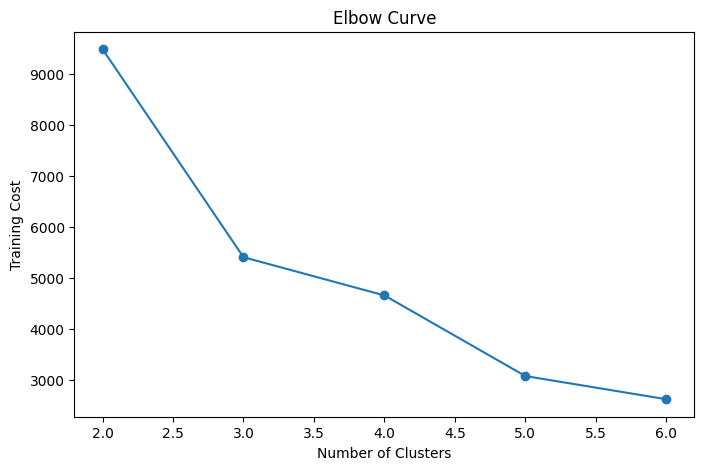

In [71]:
# -----------------------------
# 7. Elbow method
# -----------------------------
max_k = 7
cost = []

for k in range(2, max_k):
    kmeans = KMeans(featuresCol="standardized", predictionCol="prediction", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    cost.append((k, model.summary.trainingCost))

df_cost = pd.DataFrame(cost, columns=["cluster", "cost"])

plt.figure(figsize=(8, 5))
plt.plot(df_cost["cluster"], df_cost["cost"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Training Cost")
plt.title("Elbow Curve")
plt.show()

In [72]:
# -----------------------------
# 8. Train final KMeans model
# -----------------------------
optimal_k = 4

kmeans = KMeans(featuresCol="standardized", predictionCol="prediction", k=optimal_k, seed=42)
kmeans_model = kmeans.fit(scaled_data)

preds = kmeans_model.transform(scaled_data)

print("Predictions:")
preds.select("CustomerID", "recency", "frequency", "monetary_value", "prediction") \
     .show(10, truncate=False)

Predictions:
+----------+------------------+---------+------------------+----------+
|CustomerID|recency           |frequency|monetary_value    |prediction|
+----------+------------------+---------+------------------+----------+
|15039.0   |9.05486111111111  |1508     |19786.439999999944|3         |
|16553.0   |162.88055555555556|86       |5664.569999999999 |0         |
|13178.0   |25.858333333333334|265      |5725.470000000001 |1         |
|17786.0   |84.99930555555555 |72       |278.74            |1         |
|12891.0   |185.01319444444445|3        |331.0             |0         |
|16917.0   |276.03819444444446|9        |391.5200000000001 |0         |
|17966.0   |37.1              |68       |1098.43           |1         |
|15891.0   |226.01041666666666|62       |524.52            |0         |
|17955.0   |198.03472222222223|19       |557.3             |0         |
|12535.0   |91.16805555555555 |34       |716.3500000000001 |1         |
+----------+------------------+---------+----------

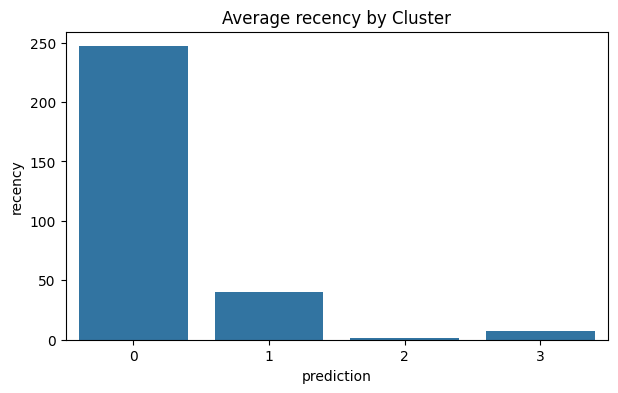

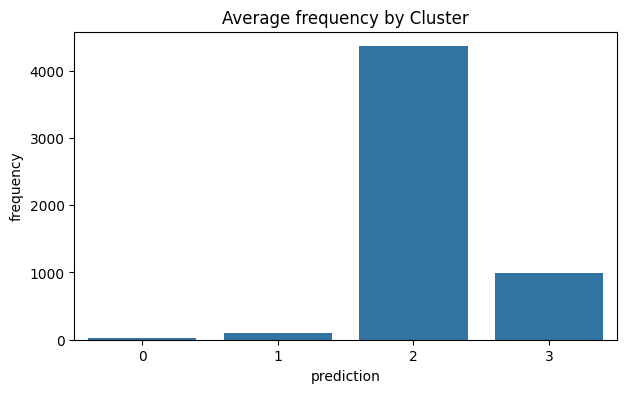

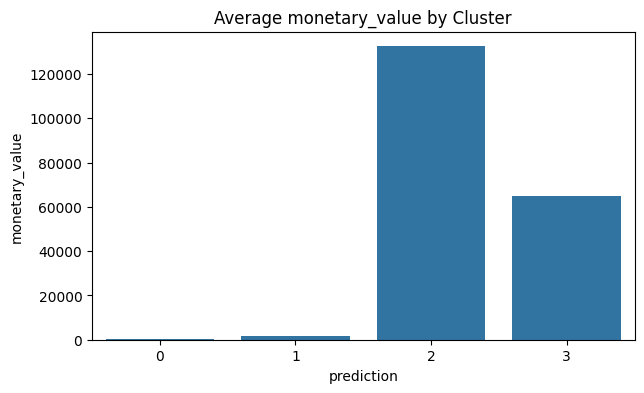

In [73]:
# -----------------------------
# 9. Cluster analysis
# -----------------------------
df_viz = preds.select("recency", "frequency", "monetary_value", "prediction").toPandas()
avg_df = df_viz.groupby("prediction", as_index=False).mean()

metrics = ["recency", "frequency", "monetary_value"]

for metric in metrics:
    plt.figure(figsize=(7, 4))
    sns.barplot(x="prediction", y=metric, data=avg_df)
    plt.title(f"Average {metric} by Cluster")
    plt.show()

In [74]:
# -----------------------------
# 10. Cluster summary
# -----------------------------
print("Cluster averages:")
print(avg_df)

spark.stop()

Cluster averages:
   prediction     recency    frequency  monetary_value
0           0  246.764402    27.710766      464.197911
1           1   39.898214   102.249385     1793.146806
2           2    1.134259  4362.333333   132505.653333
3           3    6.978742   987.166667    64719.865000


## Reference
- [DataCamp: Pyspark Tutorial: Getting Started with Pyspark](https://www.datacamp.com/tutorial/pyspark-tutorial-getting-started-with-pyspark)
- []()
- [Youtube: Adrian Dolinay - Google Colab + PySpark](https://www.youtube.com/watch?v=WkqFPxVgsqI)
- [Github: Google Colab + PySpark](https://github.com/ad17171717/YouTube-Tutorials/blob/main/Google%20Colab%20Tutorials/Google_Colab_%2B_PySpark.ipynb)